Device: cuda


Saving RCL_stock_data.csv to RCL_stock_data.csv
Saving SBUX_stock_data.csv to SBUX_stock_data.csv
Saving UNM_stock_data.csv to UNM_stock_data.csv
Saving USB_stock_data.csv to USB_stock_data.csv
Saving VMC_stock_data.csv to VMC_stock_data.csv
Saving WELL_stock_data.csv to WELL_stock_data.csv
Saving WMB_stock_data.csv to WMB_stock_data.csv
Saving XOM_stock_data.csv to XOM_stock_data.csv
Saving OKE_stock_data.csv to OKE_stock_data.csv
Saving PG_stock_data.csv to PG_stock_data.csv

Uploaded files:
RCL_stock_data.csv
SBUX_stock_data.csv
UNM_stock_data.csv
USB_stock_data.csv
VMC_stock_data.csv
WELL_stock_data.csv
WMB_stock_data.csv
XOM_stock_data.csv
OKE_stock_data.csv
PG_stock_data.csv
{'OKE': 'OKE_stock_data.csv', 'PG': 'PG_stock_data.csv', 'RCL': 'RCL_stock_data.csv', 'SBUX': 'SBUX_stock_data.csv', 'UNM': 'UNM_stock_data.csv', 'USB': 'USB_stock_data.csv', 'VMC': 'VMC_stock_data.csv', 'WELL': 'WELL_stock_data.csv', 'WMB': 'WMB_stock_data.csv', 'XOM': 'XOM_stock_data.csv'}
Number of assets:

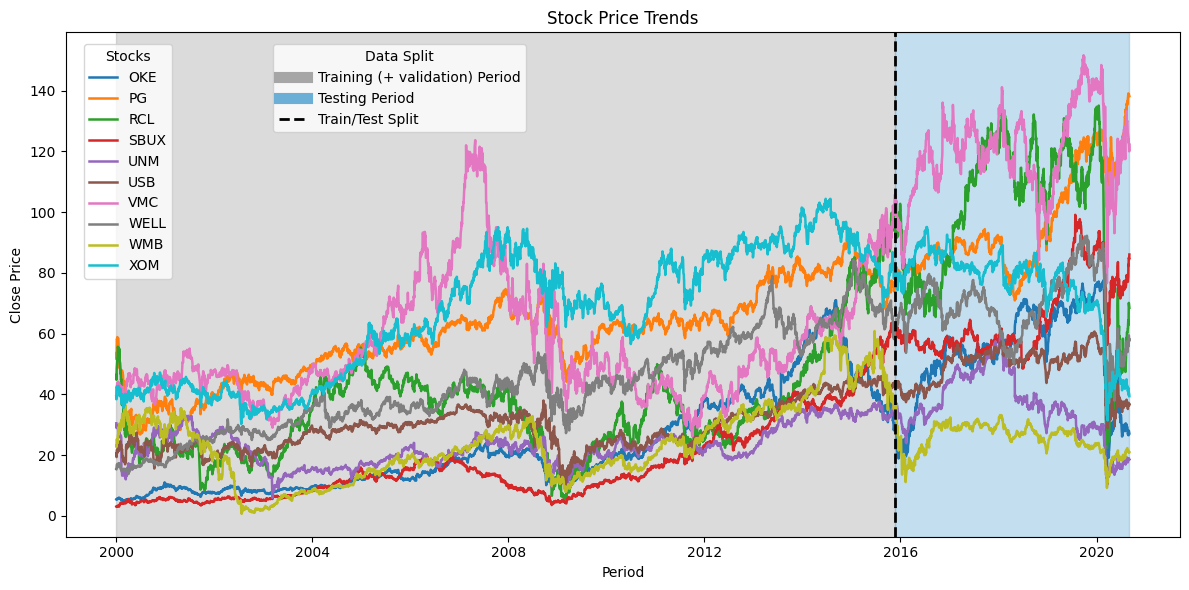

P_hat shape: torch.Size([3391, 100])
Lower bounds:
tensor([57.3547, 50.7774, 26.4745, 57.9621, 35.9231, 48.6300, 59.8467, 66.0733,
         3.9241, 66.0553])

Upper bounds:
tensor([144.8727, 132.4669, 159.7041, 150.1451, 170.2003, 189.4785, 174.5710,
        135.6705, 481.5909, 131.4404])

================ BENCHMARKS ================

Total Gain: -2.3441639741262064 Total Cost: 0.21999999999999986
Buy and Hold: {'Gain': np.float64(-307.6996768951449), 'Best': np.float64(1006.38), 'Worst': np.float64(-2027.42), 'Average': np.float64(-2.56), 'Std': np.float64(292.96), 'loss_perc': 40.0, 'gains_perc': 60.0, 'sharp_ratio': np.float64(-0.046), 'sortino_ratio': np.float64(-0.04), 'CVaR_90': np.float64(-567.603), 'CVaR_95': np.float64(-858.353), 'CVaR_99': np.float64(-1686.92)}
Buy and Hold profit: -0.7735000190734816
1/N Benchmark: {'Gain': np.float64(-30.76996768951443), 'Best': np.float64(100.64), 'Worst': np.float64(-202.74), 'Average': np.float64(-0.26), 'Std': np.float64(29.3), 'loss_pe

,Method,Overall Profit,Average Profit,Std of Profit,% Profitable Trades,% Loss Trades,Maximum Profit,Minimum Profit,Sharpe Ratio,Sortino Ratio
0,B&H,-307.700,-2.560,292.960,60.000,40.000,1006.380,-2027.420,-0.046,-0.040
1,1/N,-30.770,-0.260,29.300,60.000,40.000,100.640,-202.740,-0.046,-0.040
2,HRDNN (avg of trials),91.561,0.764,48.001,56.624,43.375,257.184,-368.438,0.056,0.110
3,HRDNN (ensemble),128.368,1.070,35.960,62.500,37.500,199.730,-302.040,0.157,0.125
4,HRDNN-GRU (avg of trials),195.503,1.630,65.109,60.251,39.750,247.791,-508.434,0.138,0.133
5,HRDNN-GRU (ensemble),220.714,1.840,63.530,65.830,34.170,243.560,-507.790,0.153,0.116




TABLE 2: CVaR COMPARISON


,Method,CVaR 90%,CVaR 95%,CVaR 99%
0,B&H,-567.603,-858.353,-1686.920
1,1/N,-56.760,-85.835,-168.692
2,HRDNN (avg of trials),-63.048,-106.326,-241.803
3,HRDNN (ensemble),-44.543,-78.924,-191.263
4,HRDNN-GRU (avg of trials),-104.861,-167.950,-382.478
5,HRDNN-GRU (ensemble),-100.382,-162.737,-382.014




TABLE 3: TRADING ACTIVITY


,Method,Turnover,Gross Exposure,Net Exposure
0,B&H,NaN,NaN,NaN
1,1/N,NaN,NaN,NaN
2,HRDNN (avg of trials),4.2485,6.7968,3.9942
3,HRDNN (ensemble),2.9654,4.6899,3.9942
4,HRDNN-GRU (avg of trials),3.7531,13.8409,12.2610
5,HRDNN-GRU (ensemble),2.3656,12.2627,12.2610


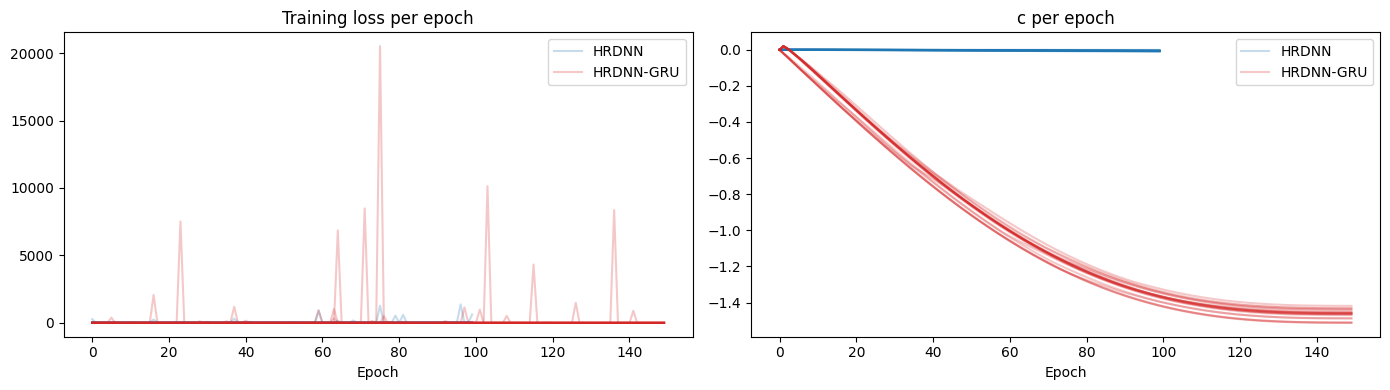

In [ ]:
# ============================================================
# CELL 1: IMPORTS + CONFIGURATION
# ============================================================

import os
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from itertools import cycle
from matplotlib.lines import Line2D

# ============================================================
# Trading parameters  (unchanged)
# ============================================================

trans_cost = 0.001
bid_ask_spread = 0.0002
borrowing_cost = 0.1

R = 10
a = 10                  # number of assets

# ============================================================
# Hyperparameters  (unchanged names kept)
# ============================================================

Epochs = 100            # original MLP setting (GRU has its own, see MODEL_CONFIGS)
Measures = 5
grids = 4
K = 1
N_trials = 20
epsilon = a
NUM_PARTITIONS = 12

# ============================================================
# NEW: GRU hyperparameters
# ============================================================

GRU_HIDDEN_MULT = 32        # GRU hidden size = 32 * a
GRU_LAYERS = 2
GRU_DROPOUT = 0.1
FEATURE_SCALE = 5.0         # fixed scaling of percent-returns (keeps model causal)

# ============================================================
# NEW: other options
# ============================================================

VAL_DAYS = 600              # last 600 training days = validation (checkpoint selection only)
EVAL_EVERY = 10             # print full TEST result every 10 epochs (as in your original)
TRAIN_WITH_FULL_COSTS = True  # training loss also pays bid-ask + borrowing (same as test)

# ============================================================
# Device
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ============================================================
# CELL 2: UPLOAD STOCK CSV FILES
# ============================================================

from google.colab import files

uploaded = files.upload()

print("\nUploaded files:")
for filename in uploaded.keys():
    print(filename)

# ============================================================
# CELL 3: STOCK FILE PATHS
# ============================================================

file_paths = {
    'OKE': "OKE_stock_data.csv",
    'PG': "PG_stock_data.csv",
    'RCL': "RCL_stock_data.csv",
    'SBUX': "SBUX_stock_data.csv",
    'UNM': "UNM_stock_data.csv",
    'USB': "USB_stock_data.csv",
    'VMC': "VMC_stock_data.csv",
    'WELL': "WELL_stock_data.csv",
    'WMB': "WMB_stock_data.csv",
    'XOM': "XOM_stock_data.csv"
}

print(file_paths)

# ============================================================
# CELL 4: LOAD STOCK DATA  (unchanged)
# ============================================================

def load_stock_data(file_paths, test_begin_day=4000, test_end_day=5200):

    data_frames = []

    for asset_name, file_path in file_paths.items():

        if os.path.exists(file_path):
            temp = pd.read_csv(file_path, parse_dates=['Date'], dayfirst=True)
            temp = temp[['Date', 'Close']]
            temp.columns = ['Date', asset_name]
            temp.dropna(inplace=True)
            data_frames.append(temp)
        else:
            print(f"Warning: {file_path} not found.")

    if not data_frames:
        raise FileNotFoundError("No valid data found in CSV files.")

    df = data_frames[0]
    for temp_df in data_frames[1:]:
        df = df.merge(temp_df, on='Date', how='outer')

    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values(by='Date').reset_index(drop=True)

    asset_list = [
        np.array(df[asset])[:test_end_day]
        for asset in file_paths.keys()
        if asset in df.columns
    ]

    return asset_list, df

# ============================================================
# CELL 5: UTILITY FUNCTIONS  (all original functions kept)
# ============================================================

def mish(x):
    return x * torch.tanh(F.softplus(x))

def ridgelet_activation(x):
    """Ridgelet activation Psi(x): Mish as admissible ridgelet nonlinearity."""
    return mish(x)

def get_slice_array1(i):
    temp = np.tile(np.arange(i + 1), a)
    return temp + np.repeat(np.arange(a), i + 1) * 8

def get_slice_array2():
    temp = np.tile(np.arange(1, 9), a)
    return temp + np.repeat(np.arange(a), 8) * 10

def get_slice_array3():
    temp = np.tile(np.arange(1, 10), a)
    return temp + np.repeat(np.arange(a), 9) * 10

def beta(x):
    return torch.pow(F.relu(x), 2)

# ============================================================
# CELL 6: RANDOM PARTITIONS + INDICATOR MATRIX
# ============================================================

def get_random_partition(stock_mins, stock_maxs, num_sets, grids=4, discrete=True):

    if grids <= 0:
        raise ValueError("grids must be > 0")

    partition = np.zeros((num_sets, 2 * a))
    stocks_len = (stock_maxs - stock_mins) / grids

    for k in range(num_sets):

        if discrete:
            lower = np.random.randint(0, grids, size=a)
            gap = np.random.randint(1, grids - lower + 1, size=a)

            partition[k, :] = np.repeat(stock_mins, 2)
            partition[k, ::2] += lower * stocks_len
            partition[k, 1::2] += (lower + gap) * stocks_len
        else:
            lower = np.random.uniform(low=stock_mins, high=stock_maxs)
            upper = stock_maxs
            partition[k, ::2] = lower
            partition[k, 1::2] = upper

    return partition


def get_indicator_matrix_original(partition, S_n):
    """YOUR ORIGINAL (slow, numpy, per-sample loop). Kept for reference."""

    B = partition.shape[0]
    indicator_matrix = np.zeros((len(S_n), 2 ** B))

    for i in range(len(S_n)):
        temp = np.ones(B, dtype=bool)
        for j in range(a):
            temp = temp & (partition[:, 2*j] < S_n[i, j])
        temp = temp.flatten().astype(int)
        pos = int(
            np.array2string(temp, formatter={'int': lambda x: bin(x)})[1:-1]
            .replace(' ', '')[2::3], 2
        )
        indicator_matrix[i][pos] = 1

    return torch.FloatTensor(indicator_matrix)


def get_indicator_matrix(partition, S_n):
    """
    Same result as get_indicator_matrix_original but vectorised on-device (fast).
    S_n: tensor (N, a)  ->  one-hot matrix (N, 2**B)
    """
    lowers = torch.as_tensor(partition[:, 0::2], dtype=S_n.dtype, device=S_n.device)
    B = lowers.shape[0]

    bits = (lowers.unsqueeze(0) < S_n.unsqueeze(1)).all(dim=2).long()      # (N, B)
    weights = 2 ** torch.arange(B - 1, -1, -1, device=S_n.device)
    pos = (bits * weights).sum(dim=1)

    M = torch.zeros(S_n.shape[0], 2 ** B, device=S_n.device)
    M[torch.arange(S_n.shape[0], device=S_n.device), pos] = 1.0
    return M

# ============================================================
# CELL 7: FRACTION VECTOR / LOSS COMPONENT
# ============================================================

def get_frac_vector(P_tau_tilde, indicator_matrix, net):

    net_input = P_tau_tilde[:, get_slice_array2()]

    delta_list, c = net(net_input)

    h_value_trans = 0
    h_value_pnl = 0
    h_value_extra = 0       # bid-ask + borrowing (only if TRAIN_WITH_FULL_COSTS)

    for i in range(a):

        delta = delta_list[i]
        p_now = P_tau_tilde[:, 10*i : 10*i + 9]
        p_next = P_tau_tilde[:, 10*i + 1 : 10*i + 10]

        trades = torch.abs(torch.cat(
            (delta[:, :1], delta[:, 1:] - delta[:, :-1], delta[:, -1:]), dim=1
        ))

        # Transaction cost
        h_value_trans = h_value_trans + trans_cost * trades.sum(dim=1)

        # Bid-ask spread + borrowing cost (match the test-time costs)
        if TRAIN_WITH_FULL_COSTS:
            h_value_extra = h_value_extra + 0.5 * bid_ask_spread * trades.sum(dim=1)
            h_value_extra = h_value_extra + (
                borrowing_cost / 252.0 * F.relu(-delta) * p_now
            ).sum(dim=1)

        # P&L
        h_value_pnl = h_value_pnl + ((p_next - p_now) * delta).sum(dim=1)

    h_value = -c + h_value_trans + h_value_extra - h_value_pnl

    temp = torch.matmul(indicator_matrix.T, h_value)
    indicator_sum = torch.sum(indicator_matrix.T, dim=1)

    indicator_sum = torch.where(
        indicator_sum.abs() > 0.5,
        indicator_sum,
        torch.ones((), device=indicator_sum.device, dtype=indicator_sum.dtype)
    )

    return temp / indicator_sum

# ============================================================
# CELL 8A: ORIGINAL HRDNN (MLP per time step)  -- kept as is
# ============================================================

class HRDNN(nn.Module):

    def __init__(self, R, a):
        super(HRDNN, self).__init__()

        self.first_layers = nn.ModuleList([nn.Linear(a * i, 32 * a) for i in range(1, 9)])
        self.bn_layers = nn.ModuleList([nn.BatchNorm1d(a * i) for i in range(1, 9)])
        self.second_layers = nn.ModuleList([nn.Linear(32 * a, 64 * a) for i in range(1, 9)])
        self.third_layers = nn.ModuleList([nn.Linear(64 * a, 128 * a) for i in range(1, 9)])
        self.fourth_layers = nn.ModuleList([nn.Linear(128 * a, a) for i in range(1, 9)])

        self.c = nn.Parameter(torch.FloatTensor([0]))
        self.delta0_s = nn.Parameter(torch.FloatTensor([0] * a))

        self.R = R
        self.a = a

    def forward(self, x):

        # Feature extraction
        output1 = [
            F.relu(self.first_layers[i](self.bn_layers[i](x[:, get_slice_array1(i)])))
            for i in range(8)
        ]

        # Second layer
        output2 = [F.relu(self.second_layers[i](output1[i])) for i in range(8)]

        # Ridgelet layer
        output3 = [ridgelet_activation(self.third_layers[i](output2[i])) for i in range(8)]

        # Trading positions
        deltas = [self.R * torch.tanh(self.fourth_layers[i](output3[i])) for i in range(8)]

        # Delta list for every asset
        delta_list = [
            torch.cat([delta[:, i:i+1] for delta in deltas], axis=1)
            for i in range(self.a)
        ]

        # Add initial position
        return [
            torch.cat(
                (self.delta0_s[i] * torch.ones((x.shape[0], 1), device=x.device),
                 delta_list[i]),
                axis=1
            )
            for i in range(self.a)
        ], self.c

# ============================================================
# CELL 8B: NEW  HRDNN-GRU
# ============================================================

class HRDNN_GRU(nn.Module):
    """
    Same interface as HRDNN: input (B, 8*a), output ([a x (B, 9)], c).

    A GRU reads the 8 price steps in order, so the position at step t only
    depends on prices up to step t (non-anticipative). One shared recurrent
    network replaces the 8 separate MLPs. The ridgelet head
    (64a -> 128a with Mish -> a, then R*tanh) is kept.
    """

    def __init__(self, R, a,
                 hidden_mult=GRU_HIDDEN_MULT,
                 num_layers=GRU_LAYERS,
                 dropout=GRU_DROPOUT):
        super().__init__()

        H = hidden_mult * a

        self.gru = nn.GRU(
            input_size=2 * a,
            hidden_size=H,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.second = nn.Linear(H, 64 * a)
        self.third = nn.Linear(64 * a, 128 * a)        # ridgelet layer
        self.fourth = nn.Linear(128 * a, a)

        self.c = nn.Parameter(torch.FloatTensor([0]))
        self.delta0_s = nn.Parameter(torch.FloatTensor([0] * a))

        self.R = R
        self.a = a

    def forward(self, x):

        B = x.shape[0]

        prices = x.reshape(B, self.a, 8).permute(0, 2, 1)                  # (B, 8, a)
        base = torch.full((B, 1, self.a), 100.0, device=x.device, dtype=x.dtype)
        full = torch.cat([base, prices], dim=1)                            # (B, 9, a)

        step_ret = full[:, 1:] - full[:, :-1]
        cum_ret = full[:, 1:] - 100.0
        feats = torch.cat([step_ret, cum_ret], dim=2) / FEATURE_SCALE

        out, _ = self.gru(feats)                                           # (B, 8, H)
        out = F.relu(self.second(out))
        out = ridgelet_activation(self.third(out))
        deltas = self.R * torch.tanh(self.fourth(out))                     # (B, 8, a)

        d0 = self.delta0_s.view(1, 1, self.a).expand(B, 1, self.a)
        deltas = torch.cat([d0, deltas], dim=1)                            # (B, 9, a)

        return [deltas[:, :, i] for i in range(self.a)], self.c


class EnsembleNet(nn.Module):
    """Averages the positions of several trained nets (same interface)."""

    def __init__(self, nets):
        super().__init__()
        self.nets = nn.ModuleList(nets)

    def forward(self, x):
        outs = [n(x) for n in self.nets]
        deltas = [
            torch.stack([o[0][i] for o in outs]).mean(dim=0)
            for i in range(len(outs[0][0]))
        ]
        c = torch.stack([o[1] for o in outs]).mean(dim=0)
        return deltas, c

# ============================================================
# CELL 9: EVALUATION  (all metrics from your original kept)
# ============================================================

ALL_METRICS = [
    'Gain', 'Best', 'Worst', 'Average', 'Std',
    'loss_perc', 'gains_perc', 'sharp_ratio', 'sortino_ratio',
    'Turnover', 'Gross_Exposure', 'Net_Exposure',
    'CVaR_90', 'CVaR_95', 'CVaR_99'
]


def window_pnl(delta, S):
    """Gain and cost of one asset over one 10-price window (raw prices)."""
    gain = np.dot(delta, S[1:10] - S[:9])

    trades = np.abs(np.concatenate([[delta[0]], np.diff(delta), [delta[-1]]]))

    cost = trans_cost * trades.sum()
    cost += 0.5 * bid_ask_spread * trades.sum()
    cost += (borrowing_cost / 252.0 * np.maximum(-delta, 0) * S[:9]).sum()

    return gain, cost


def summarize(success, gain_list, cost_list, verbose=True):

    success = np.asarray(success)

    if verbose:
        print("Total Gain:", np.array(gain_list).mean(),
              "Total Cost:", np.array(cost_list).mean())

    res = {}

    res['Gain'] = success.sum()
    res['Best'] = round(max(success), 2)
    res['Worst'] = round(min(success), 2)
    res['Average'] = round(success.mean(), 2)
    res['Std'] = round(success.std(), 2)

    res['loss_perc'] = round(100 * float(np.sum(success < 0) / len(success)), 2)
    res['gains_perc'] = round(100 * float(np.sum(success > 0) / len(success)), 2)

    ann = np.sqrt(252.0 / 9)
    neg = success[success < 0]

    res['sharp_ratio'] = round(ann * success.mean() / success.std(), 3)
    res['sortino_ratio'] = (
        round(ann * success.mean() / neg.std(), 3) if len(neg) > 1 else np.nan
    )

    var_90 = np.percentile(success, 10)
    var_95 = np.percentile(success, 5)
    var_99 = np.percentile(success, 1)

    res['CVaR_90'] = round(success[success <= var_90].mean(), 3)
    res['CVaR_95'] = round(success[success <= var_95].mean(), 3)
    res['CVaR_99'] = round(success[success <= var_99].mean(), 3)

    return res


def stat_arb_success(stock_data, net, verbose=True):
    """Model evaluation: Gain, Best, Worst, Average, Std, loss/gain %, Sharpe,
    Sortino, Turnover, Gross/Net exposure, CVaR 90/95/99."""

    W = len(stock_data[0]) // 10

    windows = [
        np.asarray(s[:W * 10], dtype=np.float64).reshape(W, 10)
        for s in stock_data
    ]

    # same input as before: 100 * S[10i+1 : 10i+9] / S[10i], asset-major
    query = np.concatenate([100 * w[:, 1:9] / w[:, [0]] for w in windows], axis=1)

    with torch.no_grad():
        out = net(torch.as_tensor(query, dtype=torch.float32, device=device))[0]

    deltas = [d.detach().cpu().numpy() for d in out]            # a x (W, 9)

    prev_delta = {k: np.zeros(9) for k in range(a)}

    success, gain_list, cost_list = [], [], []
    gross_exposure_list, net_exposure_list, turnover_list = [], [], []

    for i in range(W):

        gain = 0.0
        cost = 0.0

        for k in range(a):

            delta = deltas[k][i]

            gross_exposure_list.append(np.abs(delta).sum())
            net_exposure_list.append(delta.sum())
            turnover_list.append(np.abs(delta - prev_delta[k]).sum())
            prev_delta[k] = delta.copy()

            g, c_ = window_pnl(delta, windows[k][i])
            gain += g
            cost += c_

        success.append(gain - cost)
        gain_list.append(gain)
        cost_list.append(cost)

    res = summarize(success, gain_list, cost_list, verbose)

    res['Turnover'] = round(np.mean(turnover_list), 4)
    res['Gross_Exposure'] = round(np.mean(gross_exposure_list), 4)
    res['Net_Exposure'] = round(np.mean(net_exposure_list), 4)

    return res


def evaluate_fixed_strategy(stock_test, delta, verbose=True):
    """Benchmarks with a constant position path `delta` (length 9) per asset."""

    W = len(stock_test[0]) // 10
    success, gain_list, cost_list = [], [], []

    for i in range(W):
        gain = 0.0
        cost = 0.0
        for k in range(a):
            g, c_ = window_pnl(delta, np.asarray(stock_test[k][10*i : 10*i + 10]))
            gain += g
            cost += c_
        success.append(gain - cost)
        gain_list.append(gain)
        cost_list.append(cost)

    return summarize(success, gain_list, cost_list, verbose)


def stat_arb_success_buy_and_hold(stock_test):
    return evaluate_fixed_strategy(stock_test, 10 * np.ones(9), verbose=True)


def stat_arb_success_buy_and_hold_only_once(stock_test):

    pnl = 0

    for k in range(a):
        pnl += 10 * (stock_test[k][-1] - stock_test[k][0]) - 2 * trans_cost * 10
        pnl -= 2 * 0.5 * bid_ask_spread * 10

    print("Buy and Hold profit:", pnl / int(len(stock_test[0]) / 10))


def stat_arb_success_1overN(stock_test):
    return evaluate_fixed_strategy(stock_test, (R / a) * np.ones(9), verbose=False)


def print_result(title, res):
    """Print EVERY metric of a result dict."""
    print(f"\n{title}")
    for key in ALL_METRICS:
        if key in res:
            print(f"  {key:16s}: {res[key]}")

# ============================================================
# CELL 13: LOAD + TRAIN / VALIDATION / TEST SPLIT
# ============================================================

test_begin_day = 4000
test_end_day = 5200

asset_list, df = load_stock_data(file_paths, test_begin_day, test_end_day)

train_end_day = test_begin_day - VAL_DAYS

stock_train = [asset[:train_end_day] for asset in asset_list]
stock_val = [asset[train_end_day:test_begin_day] for asset in asset_list]
stock_test = [asset[test_begin_day:test_end_day] for asset in asset_list]

print("Number of assets:", len(asset_list))
print("Training length:", len(stock_train[0]))
print("Validation length:", len(stock_val[0]))
print("Testing length:", len(stock_test[0]))
print("DataFrame shape:", df.shape)

# ============================================================
# CELL 14: TRAIN / TEST PRICE PLOT
# ============================================================

train_start = 0
train_end = test_begin_day
test_start = test_begin_day
test_end = test_end_day

split_date = df['Date'][train_end - 1]

plt.figure(figsize=(12, 6))

plt.axvspan(df['Date'].iloc[train_start], split_date, color='#a6a6a6', alpha=0.40)
plt.axvspan(split_date, df['Date'].iloc[test_end - 1], color='#6baed6', alpha=0.40)

colors = cycle(plt.cm.tab10.colors)

for asset_name, color in zip(file_paths.keys(), colors):
    if asset_name in df.columns:
        plt.plot(df['Date'][train_start:train_end], df[asset_name][train_start:train_end],
                 linewidth=1.8, color=color, label=asset_name)
        plt.plot(df['Date'][test_start:test_end], df[asset_name][test_start:test_end],
                 linewidth=1.8, color=color)

plt.axvline(x=split_date, color='black', linestyle='--', linewidth=2)

plt.xlabel("Period")
plt.ylabel("Close Price")
plt.title("Stock Price Trends")

stock_legend = plt.legend(title="Stocks", loc='upper left', frameon=True,
                          bbox_to_anchor=(0.01, 0.99))
plt.gca().add_artist(stock_legend)

phase_legend = [
    Line2D([0], [0], color='#a6a6a6', lw=8, label='Training (+ validation) Period'),
    Line2D([0], [0], color='#6baed6', lw=8, label='Testing Period'),
    Line2D([0], [0], color='black', lw=2, linestyle='--', label='Train/Test Split')
]

plt.legend(handles=phase_legend, title="Data Split", loc='upper left',
           frameon=True, bbox_to_anchor=(0.18, 0.99))

plt.tight_layout()
plt.show()

# ============================================================
# CELL 15: CONSTRUCT P_hat  (training part only)
# ============================================================

N = len(stock_train[0])
n = 10 - 1

P_hat = np.zeros((a * (n + 1), N - n))

for j in range(a):
    for i in range(n + 1):
        P_hat[i + j * (n + 1), :] = stock_train[j][i : N - n + i]

P_hat = torch.FloatTensor(P_hat.T)

print("P_hat shape:", P_hat.shape)

# ============================================================
# CELL 16: CALCULATE STATE BOUNDS
# ============================================================

S_lower = torch.FloatTensor([100] * a)
S_upper = torch.FloatTensor([-100] * a)

for i in range(a):
    for j in range(1, n + 1):
        ratio = P_hat[:, 10*i + j] / P_hat[:, 10*i]
        S_lower[i] = torch.min(S_lower[i], torch.min(ratio))
        S_upper[i] = torch.max(S_upper[i], torch.max(ratio))

rescaled_lower_bounds = S_lower * 100 - a
rescaled_upper_bounds = S_upper * 100 + a

print("Lower bounds:")
print(rescaled_lower_bounds)

print("\nUpper bounds:")
print(rescaled_upper_bounds)

lower_np = rescaled_lower_bounds.numpy().astype(np.float64)
upper_np = rescaled_upper_bounds.numpy().astype(np.float64)

# Normalise each asset's prices ONCE (every window starts at 100), keep on device
P_norm = P_hat.clone()
for j in range(a):
    P_norm[:, 10*j : 10*(j+1)] /= (P_norm[:, 10*j] / 100).reshape(-1, 1)
P_norm = P_norm.to(device)

idx_slice3 = torch.as_tensor(get_slice_array3(), device=device)
idx_last = torch.arange(1, a + 1, device=device) * 10 - 1

# ============================================================
# CELL 17: BENCHMARKS
# ============================================================

print("\n================ BENCHMARKS ================\n")

bh_result = stat_arb_success_buy_and_hold(stock_test)
print("Buy and Hold:", bh_result)

stat_arb_success_buy_and_hold_only_once(stock_test)

one_over_n_result = stat_arb_success_1overN(stock_test)
print("1/N Benchmark:", one_over_n_result)

# ============================================================
# CELL 18: TRAINING  (original MLP HRDNN + new HRDNN-GRU)
# ============================================================

MODEL_CONFIGS = {
    # Your original model, original settings
    'HRDNN': dict(
        cls=HRDNN, epochs=100, lr=1e-4, lr_c=1e-4,
        clip=None, cosine=False, select_best=False
    ),
    # New GRU model
    'HRDNN-GRU': dict(
        cls=HRDNN_GRU, epochs=150, lr=1e-3, lr_c=2e-2,
        clip=5.0, cosine=True, select_best=True
    ),
}

MODELS_TO_RUN = ['HRDNN', 'HRDNN-GRU']      # remove one to run only the other


def train_one_trial(trial, cfg):

    np.random.seed(trial)
    torch.manual_seed(trial)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(trial)

    net = cfg['cls'](R, a).to(device)
    net.train()

    main_params = [p for name, p in net.named_parameters()
                   if name not in ('c', 'delta0_s')]

    optimizer = optim.Adam([
        {'params': main_params, 'lr': cfg['lr']},
        {'params': [net.c, net.delta0_s], 'lr': cfg['lr_c']},
    ])

    scheduler = (
        optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg['epochs'], eta_min=1e-5)
        if cfg['cosine'] else None
    )

    loss_rec = []
    c_rec = []

    best_score = -np.inf
    best_state = None
    N_samples = P_norm.shape[0]

    for epoch in range(cfg['epochs']):

        # ----- Evaluate every EVAL_EVERY epochs (full TEST result, monitoring only) -----
        if epoch % EVAL_EVERY == 0:
            net.eval()
            print("\nTest at Epoch", epoch)
            result = stat_arb_success(stock_test, net)
            print(result)
            net.train()

        # ----- Validation for checkpoint selection (GRU only) -----
        if cfg['select_best'] and (epoch % EVAL_EVERY == 0 or epoch == cfg['epochs'] - 1):
            net.eval()
            val_res = stat_arb_success(stock_val, net, verbose=False)
            score = val_res['sharp_ratio']
            print("   [validation]", {k: val_res[k] for k in
                  ('Average', 'gains_perc', 'sharp_ratio', 'sortino_ratio', 'CVaR_95')})
            if np.isfinite(score) and score > best_score:
                best_score = score
                best_state = copy.deepcopy(net.state_dict())
            net.train()

        optimizer.zero_grad()

        total_loss = 0

        partition = get_random_partition(
            lower_np, upper_np, num_sets=NUM_PARTITIONS, discrete=False
        )

        for m in range(Measures):

            P_tau_tilde = P_norm.clone()

            tau_m = torch.randn(N_samples, P_norm.shape[1] - a, device=device)
            U_epsilon = epsilon * torch.rand(1, device=device)

            tau_tilde = U_epsilon * tau_m / torch.norm(tau_m, p=2, dim=1, keepdim=True)

            P_tau_tilde[:, idx_slice3] += tau_tilde

            S_n = P_tau_tilde[:, idx_last]

            indicator_matrix = get_indicator_matrix(partition, S_n)

            frac_vector = get_frac_vector(P_tau_tilde, indicator_matrix, net)

            total_loss += (
                beta(torch.matmul(indicator_matrix, frac_vector)).sum() / N_samples
            )

        total_loss = (net.c + K * total_loss).squeeze()

        loss_rec.append(total_loss.item())
        c_rec.append(net.c.clone().detach().cpu().numpy()[0])

        total_loss.backward()

        if cfg['clip'] is not None:
            torch.nn.utils.clip_grad_norm_(net.parameters(), cfg['clip'])

        optimizer.step()

        if scheduler is not None:
            scheduler.step()

        with torch.no_grad():
            net.c.clamp_(-R, R)
            net.delta0_s.clamp_(-R, R)

    if cfg['select_best'] and best_state is not None:
        net.load_state_dict(best_state)

    net.eval()
    return net, loss_rec, c_rec


all_results = {}      # name -> dict(pnl, models, loss, c)

for model_name in MODELS_TO_RUN:

    cfg = MODEL_CONFIGS[model_name]

    all_results[model_name] = dict(pnl=[], models=[], loss=[], c=[])

    for trial in range(N_trials):

        print("\n")
        print("=" * 70)
        print(f"[{model_name}] TRIAL:", trial + 1, "/", N_trials)
        print("=" * 70)

        net, loss_rec, c_rec = train_one_trial(trial, cfg)

        record = stat_arb_success(stock_test, net)

        all_results[model_name]['pnl'].append(record)
        all_results[model_name]['models'].append(net)
        all_results[model_name]['loss'].append(loss_rec)
        all_results[model_name]['c'].append(c_rec)

        print(f"\n[{model_name}] Trial", trial + 1, "final result:")
        print(record)

# ============================================================
# CELL 19: AVERAGE RESULTS OVER ALL TRIALS (+ ensemble) -- ALL metrics
# ============================================================

average_results = {}
ensemble_results = {}

for model_name in MODELS_TO_RUN:

    pnl = all_results[model_name]['pnl']

    print("\n")
    print("=" * 70)
    print(f"FINAL {model_name} RESULT — AVERAGE OVER ALL TRIALS")
    print("=" * 70)
    print("\nNumber of trials:", len(pnl))

    average_results[model_name] = {
        m: np.nanmean([r[m] for r in pnl]) for m in ALL_METRICS
    }

    print_result(f"{model_name} — APPROXIMATE AVERAGE", average_results[model_name])

    # NEW: ensemble = average positions of all trained nets
    ens = EnsembleNet(all_results[model_name]['models']).to(device).eval()
    ensemble_results[model_name] = stat_arb_success(stock_test, ens, verbose=True)

    print_result(f"{model_name} — ENSEMBLE OF ALL TRIALS", ensemble_results[model_name])

# ============================================================
# CELL 20: FINAL COMPARISON TABLES  (all parameters)
# ============================================================

methods = ['B&H', '1/N']
results = [bh_result, one_over_n_result]

for model_name in MODELS_TO_RUN:
    methods += [f'{model_name} (avg of trials)', f'{model_name} (ensemble)']
    results += [average_results[model_name], ensemble_results[model_name]]


def col(key):
    return [r.get(key, np.nan) for r in results]


# TABLE 1: OVERALL PERFORMANCE
comparison_table = pd.DataFrame({
    'Method': methods,
    'Overall Profit': col('Gain'),
    'Average Profit': col('Average'),
    'Std of Profit': col('Std'),
    '% Profitable Trades': col('gains_perc'),
    '% Loss Trades': col('loss_perc'),
    'Maximum Profit': col('Best'),
    'Minimum Profit': col('Worst'),
    'Sharpe Ratio': col('sharp_ratio'),
    'Sortino Ratio': col('sortino_ratio'),
}).round(3)

print("\n")
print("=" * 100)
print("TABLE 1: PERFORMANCE COMPARISON")
print("=" * 100)
display(comparison_table)

# TABLE 2: CVaR
cvar_table = pd.DataFrame({
    'Method': methods,
    'CVaR 90%': col('CVaR_90'),
    'CVaR 95%': col('CVaR_95'),
    'CVaR 99%': col('CVaR_99'),
}).round(3)

print("\n")
print("=" * 60)
print("TABLE 2: CVaR COMPARISON")
print("=" * 60)
display(cvar_table)

# TABLE 3: TRADING ACTIVITY (only available for the neural models)
activity_table = pd.DataFrame({
    'Method': methods,
    'Turnover': col('Turnover'),
    'Gross Exposure': col('Gross_Exposure'),
    'Net Exposure': col('Net_Exposure'),
}).round(4)

print("\n")
print("=" * 60)
print("TABLE 3: TRADING ACTIVITY")
print("=" * 60)
display(activity_table)

# ============================================================
# CELL 21: TRAINING LOSS / c CURVES  (from loss_rec, c_rec)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for model_name in MODELS_TO_RUN:
    for k, (l, c_) in enumerate(zip(all_results[model_name]['loss'],
                                    all_results[model_name]['c'])):
        axes[0].plot(l, alpha=0.25, color='tab:blue' if model_name == 'HRDNN' else 'tab:red',
                     label=model_name if k == 0 else None)
        axes[1].plot(c_, alpha=0.25, color='tab:blue' if model_name == 'HRDNN' else 'tab:red',
                     label=model_name if k == 0 else None)

axes[0].set_title("Training loss per epoch")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].set_title("c per epoch")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()